### IMPORTS

In [1]:
import pandas as pd

In [2]:
from data_ingestion import data_ingest
from data_transformation import data_transform, segmentation

### DATA INGESTION

In [3]:
# START FETCHING BITCOIN PRICES WITH AN INTERVAL OF 1 MIN AND SAVE IN DATAFRAME
# data_ingest()

In [4]:
df = pd.read_csv("data.csv")
df.head()

,time,price,date
0,22:11:03.919435,84218,2025-04-13
1,22:12:04.032894,84243,2025-04-13
2,22:13:04.158747,84257,2025-04-13
3,22:14:04.277375,84268,2025-04-13
4,22:15:04.415592,84238,2025-04-13


### DATA TRANSFORMATION

In [5]:
# Feature engineering and creating window for data segmentation
df = data_transform(df, window=5)
df.head()

2025-04-25 17:24:57.045 | INFO     | data_transformation:data_transform:23 - Segmented data with window size of: 5


,time,price,date,perc_change,movement,window
0,22:11:03.919435,84218,2025-04-13,0.000000,stable,0
1,22:12:04.032894,84243,2025-04-13,0.029685,medium_up,0
2,22:13:04.158747,84257,2025-04-13,0.016619,stable,0
3,22:14:04.277375,84268,2025-04-13,0.013055,stable,0
4,22:15:04.415592,84238,2025-04-13,-0.035601,medium_down,0


In [6]:
# Segmenting data into documents basis window size of 5
documents = segmentation(df)
documents[:5]

2025-04-25 17:24:57.076 | INFO     | data_transformation:segmentation:30 - Segmented data into documents


[['stable', 'medium_up', 'stable', 'stable', 'medium_down'],
 ['stable', 'large_up', 'stable', 'medium_up', 'stable'],
 ['medium_up', 'stable', 'stable', 'stable', 'stable'],
 ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up'],
 ['large_up', 'large_up', 'medium_up', 'large_up', 'large_up']]

### VECTORIZATION

In [7]:
from vectorization import word2vec, fasttext, doc_tagger, do2vec

In [8]:
# Creating a Word2Vec Model
w2v_model = word2vec(documents)

# Creating a FastText Vector Model
ft_model = fasttext(documents)

# Creating a Doc2Vec Model
tagged_docs = doc_tagger(documents)
d2v_model = do2vec(tagged_docs)

2025-04-25 17:24:57.432 | INFO     | vectorization:word2vec:8 - Vectorization completed using Word2Vec Model
2025-04-25 17:24:57.673 | INFO     | vectorization:fasttext:13 - Vectorization completed using Fast Text Model
2025-04-25 17:24:57.673 | INFO     | vectorization:doc_tagger:18 - Document Tagging completed
2025-04-25 17:24:57.678 | INFO     | vectorization:do2vec:24 - Document Vectorization completed using Doc2Vec Model


### TOPIC MODELING

In [9]:
from topic_modeling import corpus_creation, lda_modeling, lsi_modeling

In [10]:
# Creating dictionary and corpus for our topic models
dictionary, corpus = corpus_creation(documents)

# Creating LDA Model with 2 topics
lda_model = lda_modeling(dictionary, corpus, num_topics=2)

# Creating LSI Model with 2 topics
lsi_model = lsi_modeling(dictionary, corpus, num_topics=2)

# By the topic scoring we can get an idea of whether the topic is bullish, bearish or stable
# Insight you get:

# Topic 0 = Bearish periods 
# (since 80% of tokens are either 'stable' or 'medium_down/large_down')
# '0.645*"stable" + 0.223*"medium_down" + 0.060*"large_down" + 0.056*"medium_up" + 0.017*"large_up"'

# Topic 1 = Bulllish periods 
# '0.526*"large_up" + 0.371*"medium_up" + 0.050*"stable" + 0.031*"medium_down" + 0.022*"large_down"'
# (90% up)
# '''

2025-04-25 17:24:57.687 | INFO     | topic_modeling:corpus_creation:10 - Dictionary and Corpus created for Topic Modeling


LDA Modeling done with following topics
(0, '0.526*"large_up" + 0.359*"medium_up" + 0.066*"stable" + 0.028*"medium_down" + 0.022*"large_down"')
(1, '0.637*"stable" + 0.225*"medium_down" + 0.062*"medium_up" + 0.060*"large_down" + 0.016*"large_up"')
LSI Modeling done with following topics
(0, '0.919*"stable" + 0.251*"medium_down" + 0.220*"medium_up" + 0.204*"large_up" + 0.049*"large_down"')
(1, '0.848*"large_up" + 0.443*"medium_up" + -0.260*"stable" + -0.118*"medium_down" + -0.043*"large_down"')


### ANALYSIS

In [11]:
from analysis import vector_model_topic_similarity, vecmodel_window_similarity, similar_d2v_time, d2v_cosine_sim_heatmap, word2v_cosine_sim_heatmap, topic_model_cos_sim, sub_dataframe

In [12]:
similarity_df_w2v = vector_model_topic_similarity(w2v_model)
print("Similarity matrix based on Word2Vec Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_w2v)

similarity_df_fasttext = vector_model_topic_similarity(ft_model)
print("Similarity matrix based on FastText Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_fasttext)

similarity_df_d2v = vector_model_topic_similarity(d2v_model)
print("Similarity matrix based on Doc2Vec Model")
print(vector_model_topic_similarity.__doc__)
print(similarity_df_d2v)

Similarity matrix based on Word2Vec Model

    What does function tells? Basis similarity matrix we can conclude -
    In a trending market, "large_up" might be highly similar to "large_down"
    In a volatile market, "large_up" might be highly similar to "medium_down"
    
               stable  large_up  medium_up  medium_down  large_down
stable       1.000000  0.042373   0.126701    -0.014475   -0.118213
large_up     0.042373  1.000000   0.011072    -0.174248    0.124863
medium_up    0.126701  0.011072   1.000000    -0.155156    0.165636
medium_down -0.014475 -0.174248  -0.155156     1.000000   -0.206005
large_down  -0.118213  0.124863   0.165636    -0.206005    1.000000
Similarity matrix based on FastText Model

    What does function tells? Basis similarity matrix we can conclude -
    In a trending market, "large_up" might be highly similar to "large_down"
    In a volatile market, "large_up" might be highly similar to "medium_down"
    
               stable  large_up  medium_up

In [13]:
# Selecting documents
doc1 = documents[3]
doc2 = documents[-1]

print(vecmodel_window_similarity.__doc__)
print("Doc1:",doc1)
print("Doc2:",doc2)

# Similarity based on Word2Vec Model
vecmodel_window_similarity(w2v_model, doc1, doc2)

# Similarity based on FastText Model
vecmodel_window_similarity(ft_model, doc1, doc2)

# Similarity based on Doc2Vec Model
vecmodel_window_similarity(d2v_model, doc1, doc2)

Checking similarity between segmented data (2 documents) using vectorization model
Doc1: ['medium_up', 'large_up', 'medium_up', 'medium_up', 'large_up']
Doc2: ['medium_down', 'stable', 'stable', 'stable', 'stable']
Similarity: 0.0758
Similarity: -0.0516
Similarity: 0.0757


In [14]:
doc = documents[-1]

# Finding top 5 similar documents/timeframes to the given document
print(similar_d2v_time.__doc__)
similar_d2v_time(df, d2v_model, doc)


    Finding top 5 similar documents/timeframes to the given document.
    So that we can check what is the most similar history and it's result to invest accordingly
    
Top 5 similar timeframes
Timeframe: 2025-04-13, 22:56:09.922406 To 2025-04-13, 23:00:10.413999 Similarity: 0.16849148273468018
Timeframe: 2025-04-13, 22:31:06.536787 To 2025-04-13, 22:35:07.078730 Similarity: 0.1541602909564972
Timeframe: 2025-04-13, 23:01:10.564831 To 2025-04-13, 23:05:11.091273 Similarity: 0.029103703796863556
Timeframe: 2025-04-13, 22:11:03.919435 To 2025-04-13, 22:15:04.415592 Similarity: 0.023079194128513336
Timeframe: 2025-04-13, 22:26:05.858843 To 2025-04-13, 22:30:06.407049 Similarity: -0.01839175820350647


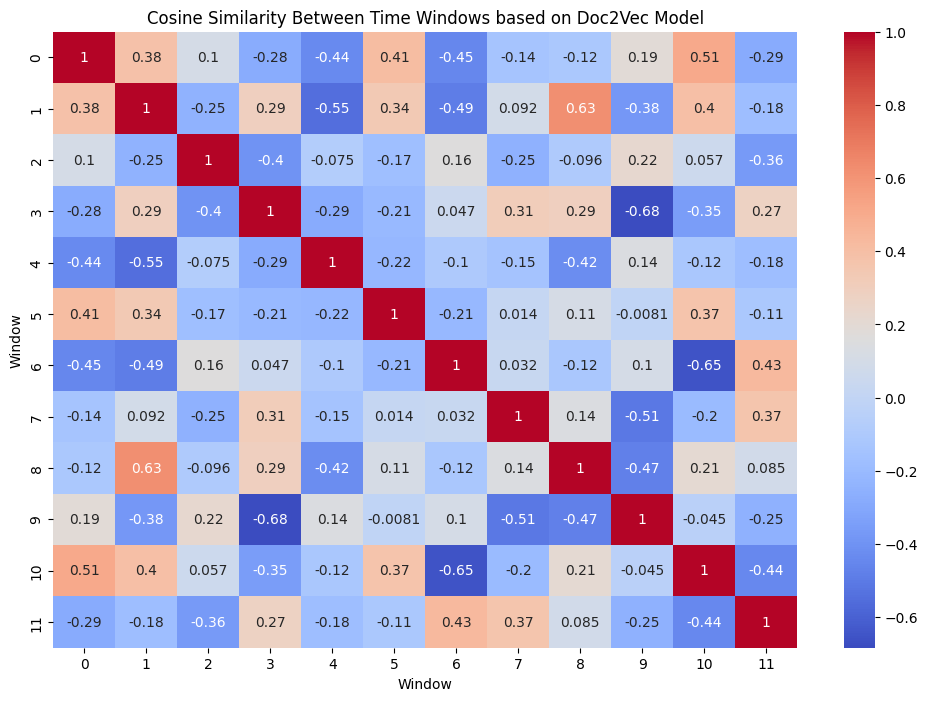

In [15]:
d2v_cosine_sim_heatmap(d2v_model,tagged_docs)

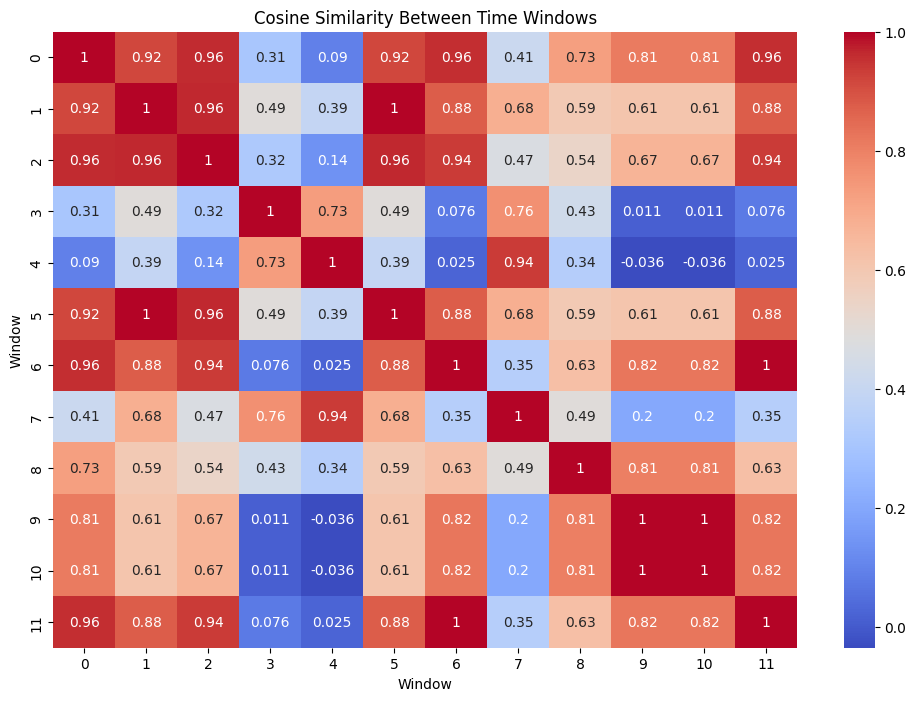

In [16]:
word2v_cosine_sim_heatmap(w2v_model,documents)

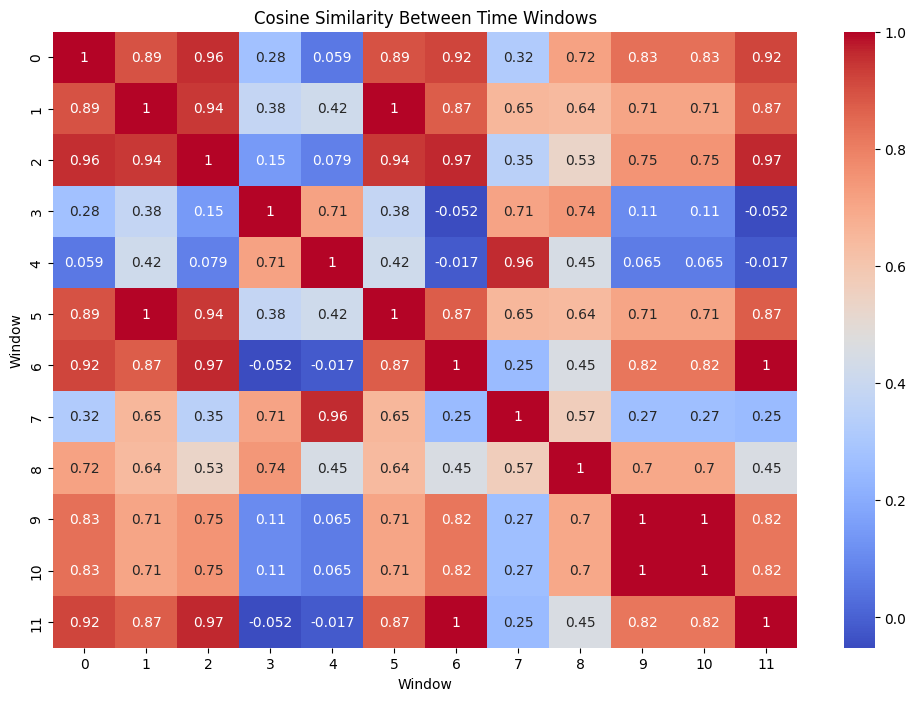

In [17]:
word2v_cosine_sim_heatmap(ft_model,documents)

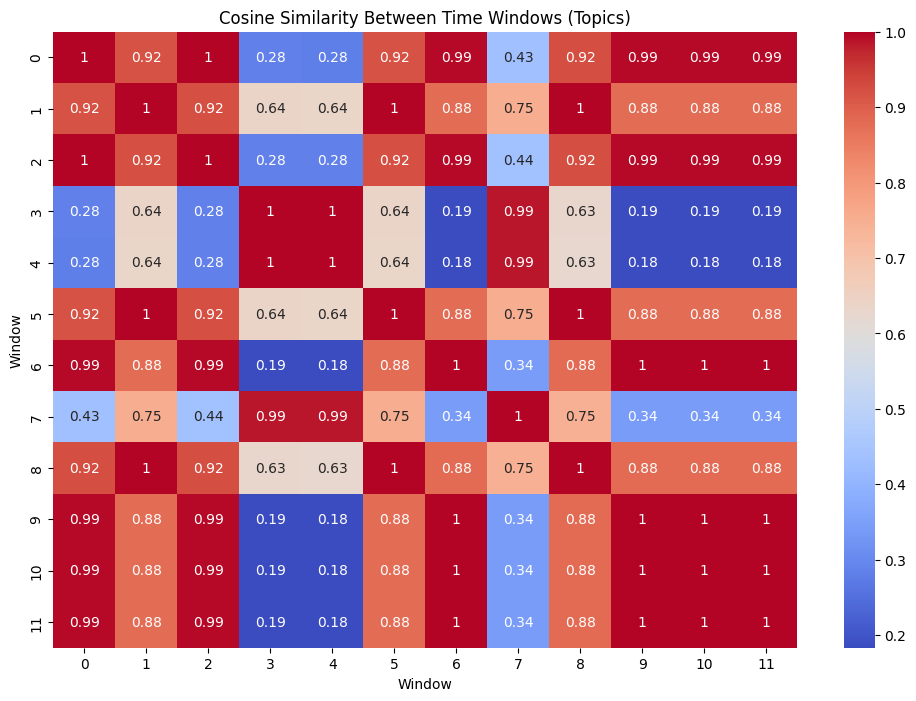

In [18]:
topic_model_cos_sim(lda_model, corpus)

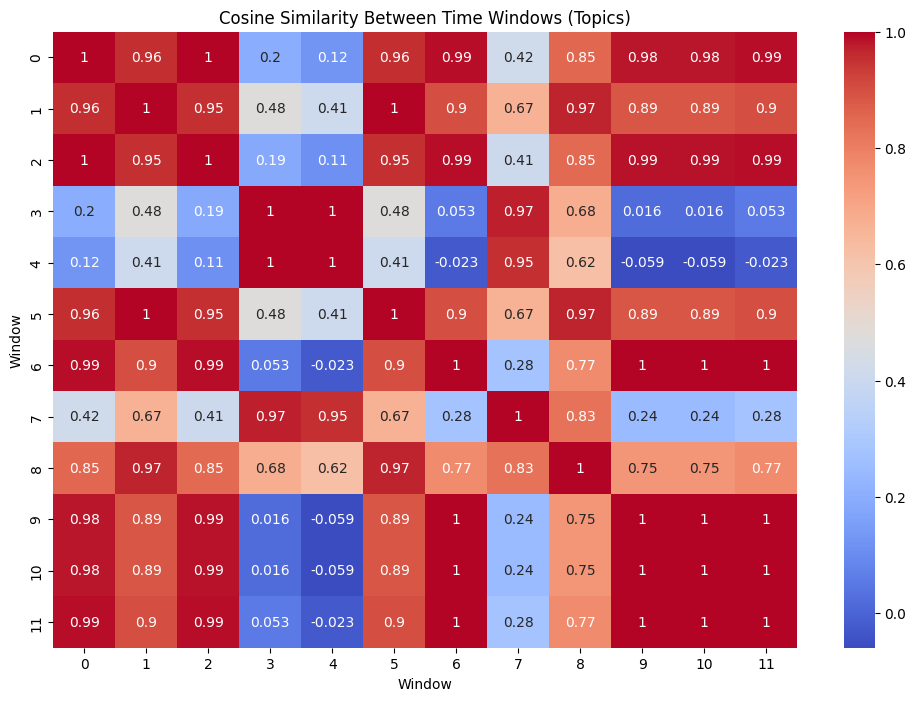

In [19]:
topic_model_cos_sim(lsi_model, corpus)

In [ ]:
# Pull out data to check Bitcoin price
sub_dataframe(df, 0)

time           22:11:03.919435
price                    84218
date                2025-04-13
perc_change                0.0
movement                stable
window                       0
Name: 0, dtype: object